In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import time
import joblib
import gensim.downloader as api #Para los embeggings preentrenados

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')
plt.style.use("ggplot")

In [3]:
glove_model = api.load("glove-twitter-100") #cargo del modelo GloVe sobre tweets con vectores 100 dimensiones.

In [4]:
X_train_clean = joblib.load("../Clean/X_train_clean.pkl")
X_test_clean  = joblib.load("../Clean/X_test_clean.pkl")
y_train       = joblib.load("../Clean/y_train_clean.pkl")
y_test        = joblib.load("../Clean/y_test_clean.pkl")

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [6]:
tfidf_vectorizer = joblib.load("../Vectorización/tfidf_vectorizer.pkl")

In [7]:
# Función que transforma cada tweet en un vector promedio ponderado por TF-IDF de embeddings GloVe
def tweet_a_vector(texto, glove_model,tfidf_vectorizer, dim=100):
    palabras = texto.split()
    vocab_tfidf = tfidf_vectorizer.vocabulary_ 
    idf = tfidf_vectorizer.idf_
    
    vectores = []
    pesos = []
    for w in palabras: 
        if w in glove_model and w in vocab_tfidf:
            vectores.append(glove_model[w])
            pesos.append(idf[vocab_tfidf[w]])
            
    if len(vectores) == 0:
        return np.zeros(dim)
        
    vectores = np.array(vectores)
    pesos = np.array(pesos)
    return np.average(vectores, axis=0, weights=pesos)

In [8]:
#Aplicamos la función tweet_a_vector a X_train_clear y X_test_clear
inicio = time.time()
X_train_emb = np.array([tweet_a_vector(t, glove_model, tfidf_vectorizer) for t in X_train_clean])
X_test_emb = np.array([tweet_a_vector(t, glove_model, tfidf_vectorizer) for t in X_test_clean])
fin = time.time()
print(f"Tiempo de vectorización: {fin - inicio:.2f} segundos")

Tiempo de vectorización: 77.87 segundos


**RL + GloVe**

In [9]:
from sklearn.linear_model import LogisticRegression

In [10]:
logreg_emb = LogisticRegression(max_iter=2000, random_state=42, n_jobs=-1)
logreg_emb.fit(X_train_emb, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"n_jobs n_jobs: int, default=NoneDoes not have any effect... deprecated:: 1.8 `n_jobs` is deprecated in version 1.8 and will be removed in 1.10.",-1
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None


In [11]:
y_train_pred_emb = logreg_emb.predict(X_train_emb)
y_test_pred_emb  = logreg_emb.predict(X_test_emb)

In [12]:
print("Train (RL + Embeddings preentrenados)")
print(classification_report(y_train, y_train_pred_emb))
print("--------------------------------------------------")
print("Test (RL + Embeddings preentrenados)")
print(classification_report(y_test, y_test_pred_emb))

Train (RL + Embeddings preentrenados)
              precision    recall  f1-score   support

          -1       0.73      0.72      0.72    637069
           1       0.72      0.73      0.73    637083

    accuracy                           0.73   1274152
   macro avg       0.73      0.73      0.73   1274152
weighted avg       0.73      0.73      0.73   1274152

--------------------------------------------------
Test (RL + Embeddings preentrenados)
              precision    recall  f1-score   support

          -1       0.73      0.72      0.72    159268
           1       0.72      0.73      0.73    159271

    accuracy                           0.73    318539
   macro avg       0.73      0.73      0.73    318539
weighted avg       0.73      0.73      0.73    318539



In [13]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

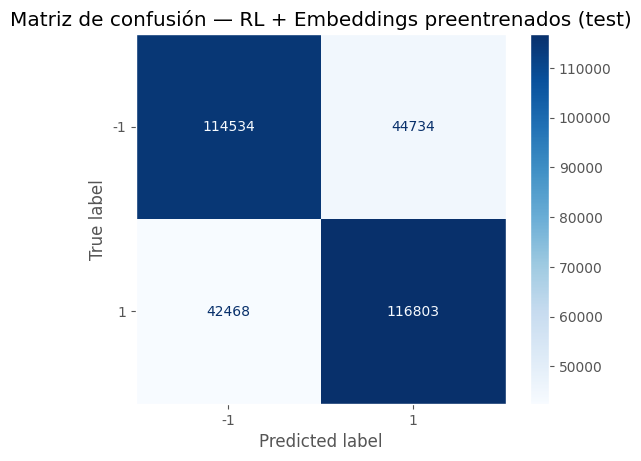

In [14]:
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred_emb, cmap="Blues")
plt.title("Matriz de confusión — RL + Embeddings preentrenados (test)")
plt.grid(False) 
plt.show()

In [15]:
os.makedirs("../Modelos", exist_ok=True)
joblib.dump(logreg_emb, "../Modelos/logreg_embeddings.pkl")

['../Modelos/logreg_embeddings.pkl']

## Comparación ##

In [16]:
tfidf = joblib.load("../Vectorización/tfidf_vectorizer.pkl")
X_test_tfidf = joblib.load("../Vectorización/X_test_tfidf.pkl")
y_test_tfidf = joblib.load("../Vectorización/y_test.pkl")
logreg = joblib.load("../Modelos/logreg_tfidf.pkl")
bow = joblib.load("../Vectorización/bow_vectorizer.pkl")
nbayes_bow = joblib.load("../Modelos/nbayes_bow.pkl")
X_test_bow = bow.transform(X_test_clean)

In [18]:
print("----------------------------------------------")
print("Comparación RL + TF-IDF vs NB + BoW vs Embeddings vs TextBlob")
print("----------------------------------------------")
accu_rl = logreg.score(X_test_tfidf, y_test_tfidf)
accu_nb = nbayes_bow.score(X_test_bow, y_test)
accu_emb_rl = logreg_emb.score(X_test_emb, y_test)
accu_textblob = joblib.load("../Modelos/textblob_accuracy.pkl") 
comparacion = pd.DataFrame({
    "Modelo": ["RL + TF-IDF", "NB + BoW", "RL + Embeddings preentrenados",  "TextBlob (preentrenado)"],
    "Accuracy (test)": [accu_rl, accu_nb, accu_emb_rl, accu_textblob]
})
display(comparacion)

----------------------------------------------
Comparación RL + TF-IDF vs NB + BoW vs Embeddings vs TextBlob
----------------------------------------------


,Modelo,Accuracy (test)
0,RL + TF-IDF,0.798750
1,NB + BoW,0.772540
2,RL + Embeddings preentrenados,0.726244
3,TextBlob (preentrenado),0.623214
